# Cobras e Escadas — solução computacional

**Objetivo.** Responder às 5 perguntas com simulações de **10.000 partidas por cenário**, registrando cada passo.

**Estratégia.**
1. Codificar o tabuleiro como dados e validar a leitura (testes + desenho).
2. Escrever um motor de jogo único, parametrizado pelas regras de cada cenário (escada a 50%, casa inicial do J2, imunidade).
3. Testar o motor com dados "roteirizados", isto é, sequências de lances fixas com resultado conhecido.
4. Rodar o Monte Carlo com semente fixa e reportar cada resposta com **intervalo de confiança de 95%**.
5. **Validar** tudo contra uma solução exata independente (cadeia de Markov) para provar que o simulador está correto.

## 0. Configuração

In [1]:
from __future__ import annotations

import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_JOGOS = 10_000          # pedido no enunciado
SEMENTE = 2026            # reprodutibilidade
Z95 = 1.959964

# Paleta e estilo dos gráficos
AZUL, LARANJA = "#2a78d6", "#eb6834"
TXT, TXT2, GRADE = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRADE, "axes.labelcolor": TXT2, "axes.titlecolor": TXT,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": GRADE, "grid.linewidth": 0.8, "xtick.color": TXT2,
    "ytick.color": TXT2, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 2,
})
pd.set_option("display.precision", 4)

## 1. O tabuleiro como dados

Leitura da figura (origem → destino):

| Escadas (base → topo) | Cobras (cabeça → rabo) |
|---|---|
| 3 → 16, 5 → 7, 15 → 25, 18 → 20, 21 → 32 | 12 → 2, 14 → 11, 17 → 4, 31 → 19, 35 → 22 |

Tudo o que depende da leitura da imagem está **somente** nestes dois dicionários. Se a leitura de alguma casa mudar, basta editar aqui; o restante do notebook se recalcula.

In [2]:
ULTIMA_CASA = 36
ESCADAS = {3: 16, 5: 7, 15: 25, 18: 20, 21: 32}
COBRAS  = {12: 2, 14: 11, 17: 4, 31: 19, 35: 22}

# --- validação estrutural da leitura ---------------------------------------
assert all(a < b for a, b in ESCADAS.items()), "escada tem que subir"
assert all(a > b for a, b in COBRAS.items()),  "cobra tem que descer"
gatilhos = set(ESCADAS) | set(COBRAS)
assert len(gatilhos) == len(ESCADAS) + len(COBRAS), "casa com escada E cobra"
assert not (set(ESCADAS.values()) | set(COBRAS.values())) & gatilhos, \
    "destino que dispara outro gatilho (encadeamento) não previsto nas regras"
assert all(1 <= c <= ULTIMA_CASA for c in gatilhos | set(ESCADAS.values()) | set(COBRAS.values()))
print("Tabuleiro OK:", len(ESCADAS), "escadas,", len(COBRAS), "cobras")

Tabuleiro OK: 5 escadas, 5 cobras


Desenho do tabuleiro gerado **a partir dos dicionários** (numeração em zigue-zague, como na figura). Serve para conferir visualmente a leitura contra a imagem original.

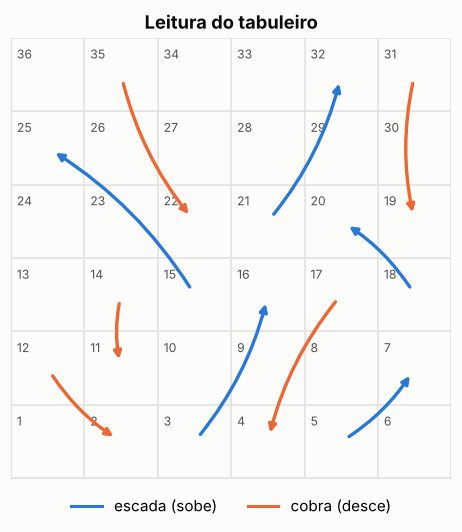

In [3]:
def coord(casa: int) -> tuple[float, float]:
    # Centro da casa no tabuleiro 6x6 em zigue-zague (linha 0 embaixo).
    lin, k = divmod(casa - 1, 6)
    col = k if lin % 2 == 0 else 5 - k
    return col + 0.5, lin + 0.5

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.set_xlim(0, 6); ax.set_ylim(0, 6); ax.set_aspect("equal"); ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
for c in range(1, ULTIMA_CASA + 1):
    x, y = coord(c)
    ax.add_patch(plt.Rectangle((x - .5, y - .5), 1, 1, fc="#fcfcfb", ec=GRADE))
    ax.text(x - .42, y + .38, c, fontsize=8, color=TXT2, va="top")
for mapa, cor in ((ESCADAS, AZUL), (COBRAS, LARANJA)):
    for a, b in mapa.items():
        (x0, y0), (x1, y1) = coord(a), coord(b)
        ax.annotate("", (x1, y1), (x0, y0), arrowprops=dict(
            arrowstyle="-|>", color=cor, lw=2.2, shrinkA=6, shrinkB=6,
            connectionstyle="arc3,rad=0.12"))
ax.plot([], [], color=AZUL, label="escada (sobe)")
ax.plot([], [], color=LARANJA, label="cobra (desce)")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.01), ncol=2)
ax.set_title("Leitura do tabuleiro")
plt.show()

## 2. Motor do jogo

Um único motor serve aos 5 cenários: as variações entram pela dataclass `Regras`.

**Regras implementadas:**
- Os jogadores alternam lances de um d6, e o J1 começa.
- Chegar **ou passar** da casa 36 vence, então a posição é truncada em 36.
- Escadas e cobras são aplicadas uma única vez por lance, já que não há encadeamento (validado acima).
- **Q3:** ao cair na base de uma escada, o jogador sobe com probabilidade `p_escada`. Caso contrário, permanece na base.
- **Q5:** a primeira cobra em que o J2 cair é ignorada. Ele permanece na cabeça e a imunidade é consumida.

O gerador aleatório é injetado (`rng`). Isso garante reprodutibilidade e permite testar o motor com dados roteirizados.

In [4]:
@dataclass(frozen=True)
class Regras:
    inicio_j2: int = 1
    p_escada: float = 1.0          # Q3: 0.5
    imunidade_j2: bool = False     # Q5


@dataclass
class Jogador:
    casa: int
    imune: bool = False
    lances: int = 0
    cobras: int = 0
    escadas: int = 0

    def jogar(self, rng, p_escada: float) -> bool:
        # Executa um lance; devolve True se o jogador venceu.
        self.lances += 1
        destino = min(self.casa + rng.randint(1, 6), ULTIMA_CASA)

        if destino in ESCADAS:
            # p_escada == 1 não consome número aleatório (mantém fluxos comparáveis)
            if p_escada >= 1 or rng.random() < p_escada:
                destino = ESCADAS[destino]
                self.escadas += 1
        elif destino in COBRAS:
            if self.imune:
                self.imune = False          # imunidade gasta; fica na cabeça
            else:
                destino = COBRAS[destino]
                self.cobras += 1

        self.casa = destino
        return destino == ULTIMA_CASA


def jogar_partida(regras: Regras, rng) -> dict:
    jogadores = (Jogador(1), Jogador(regras.inicio_j2, imune=regras.imunidade_j2))
    vez = 0
    while not jogadores[vez].jogar(rng, regras.p_escada):
        vez ^= 1
    j1, j2 = jogadores
    return {"vencedor": vez + 1,
            "lances": j1.lances + j2.lances,
            "cobras_j1": j1.cobras, "cobras_j2": j2.cobras,
            "escadas_j1": j1.escadas, "escadas_j2": j2.escadas}

### 2.1 Testes do motor com dados roteirizados

In [5]:
class DadoRoteirizado:
    # Substitui o rng: devolve lances e sorteios pré-definidos.
    def __init__(self, dados, sorteios=()):
        self.dados, self.sorteios = list(dados), list(sorteios)
    def randint(self, a, b): return self.dados.pop(0)
    def random(self): return self.sorteios.pop(0)

def lance(casa, d, p=1.0, imune=False, sorteios=()):
    j = Jogador(casa, imune=imune)
    venceu = j.jogar(DadoRoteirizado([d], sorteios), p)
    return j.casa, venceu, j.cobras, j.imune

assert lance(1, 2)[0] == 16                       # escada 3 -> 16
assert lance(1, 4)[0] == 7                        # escada 5 -> 7
assert lance(10, 4)[0] == 11                      # cobra 14 -> 11
assert lance(30, 5)[:3] == (22, False, 1)         # cobra 35 -> 22, conta 1
assert lance(33, 6)[:2] == (36, True)             # passar de 36 vence
assert lance(30, 6)[:2] == (36, True)             # cair exato em 36 vence
assert lance(1, 2, p=.5, sorteios=[.7])[0] == 3   # escada falha: fica na base
assert lance(1, 2, p=.5, sorteios=[.2])[0] == 16  # escada funciona
assert lance(10, 2, imune=True) == (12, False, 0, False)   # imunidade usada
assert lance(10, 2, imune=False)[0] == 2

# partida roteirizada: J1 1->3->16 | J2 1->2 | J1 16->21->32 | J2 2->3->16 | J1 32->36
p = jogar_partida(Regras(), DadoRoteirizado([2, 1, 5, 1, 4]))
assert (p["vencedor"], p["lances"], p["escadas_j1"], p["escadas_j2"]) == (1, 5, 2, 1), p
print("Todos os testes do motor passaram.")

Todos os testes do motor passaram.


## 3. Monte Carlo

Cada cenário roda com o próprio gerador, derivado da semente mestre (`SEMENTE + id`). Assim os cenários são **independentes**, como pede o enunciado, e o notebook é reprodutível.

**Incertezas reportadas:**
- Proporções: intervalo de **Wilson** a 95%.
- Médias: média ± 1,96·s/√n.

In [6]:
def simular(regras: Regras, n: int = N_JOGOS, semente: int = SEMENTE) -> pd.DataFrame:
    rng = random.Random(semente)
    return pd.DataFrame([jogar_partida(regras, rng) for _ in range(n)])


def ic_proporcao(k: int, n: int) -> tuple[float, float, float]:
    p = k / n
    den = 1 + Z95**2 / n
    centro = (p + Z95**2 / (2 * n)) / den
    meia = Z95 * np.sqrt(p * (1 - p) / n + Z95**2 / (4 * n**2)) / den
    return p, centro - meia, centro + meia


def ic_media(x) -> tuple[float, float, float]:
    x = np.asarray(x, float)
    m, e = x.mean(), Z95 * x.std(ddof=1) / np.sqrt(x.size)
    return m, m - e, m + e


fmt = lambda t, d=4: f"{t[0]:.{d}f}  [IC95%: {t[1]:.{d}f}, {t[2]:.{d}f}]"
RESPOSTAS = {}

## 4. Respostas

### Pergunta 1 — P(jogador que começa vencer)

Basta contar em quantas das 10.000 partidas o J1 venceu.

In [7]:
base = simular(Regras(), semente=SEMENTE + 1)
q1 = ic_proporcao((base.vencedor == 1).sum(), len(base))
RESPOSTAS["Q1  P(J1 vence)"] = q1
print("P(J1 vence) =", fmt(q1))

P(J1 vence) = 0.5308  [IC95%: 0.5210, 0.5406]


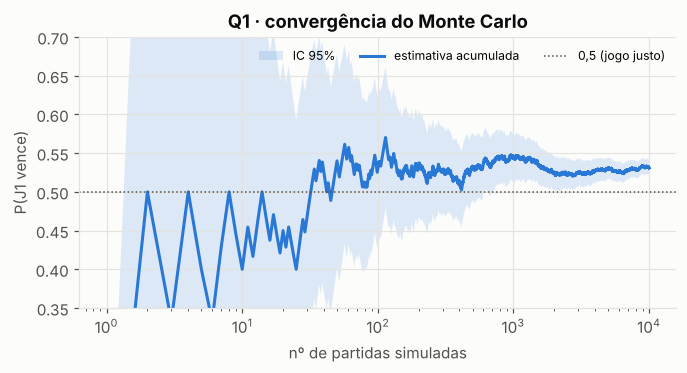

In [8]:
# Convergência da estimativa ao longo das partidas
x = (base.vencedor == 1).to_numpy().cumsum() / np.arange(1, len(base) + 1)
n = np.arange(1, len(base) + 1)
e = Z95 * np.sqrt(x * (1 - x) / n)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.fill_between(n, x - e, x + e, color=AZUL, alpha=.15, lw=0, label="IC 95%")
ax.plot(n, x, color=AZUL, label="estimativa acumulada")
ax.axhline(.5, color=TXT2, lw=1, ls=":", label="0,5 (jogo justo)")
ax.set(xscale="log", ylim=(.35, .7), xlabel="nº de partidas simuladas",
       ylabel="P(J1 vence)", title="Q1 · convergência do Monte Carlo")
ax.legend(loc="upper right", ncol=3, fontsize=8)
plt.show()

### Pergunta 2 — cobras por partida

Somo as cobras dos **dois** jogadores em cada partida e tiro a média. Também reporto a quebra por jogador.

In [9]:
total_cobras = base.cobras_j1 + base.cobras_j2
q2 = ic_media(total_cobras)
RESPOSTAS["Q2  cobras por partida (total)"] = q2
print("Cobras por partida (J1+J2):", fmt(q2, 3))
print("  J1:", fmt(ic_media(base.cobras_j1), 3))
print("  J2:", fmt(ic_media(base.cobras_j2), 3))
print("\nDistribuição do nº de cobras por partida:")
print(total_cobras.value_counts(normalize=True).sort_index().head(10).round(4).to_string())

Cobras por partida (J1+J2): 3.089  [IC95%: 3.038, 3.139]
  J1: 1.592  [IC95%: 1.562, 1.621]
  J2: 1.497  [IC95%: 1.468, 1.526]

Distribuição do nº de cobras por partida:
0    0.1195
1    0.1915
2    0.1880
3    0.1522
4    0.1099
5    0.0815
6    0.0547
7    0.0381
8    0.0228
9    0.0163


### Pergunta 3 — escadas funcionam só 50% das vezes

Interpreto "lançamentos para completar um jogo" como o total de lances da partida, somando os dois jogadores. Como referência, também calculo o número de lances de um jogador sozinho até chegar ao fim e o caso com escadas normais.

In [10]:
reg_q3 = Regras(p_escada=0.5)
q3_df = simular(reg_q3, semente=SEMENTE + 3)
q3 = ic_media(q3_df.lances)
RESPOSTAS["Q3  lances por partida (escada 50%)"] = q3


def lances_solo(p_escada: float, n: int, semente: int) -> np.ndarray:
    rng, out = random.Random(semente), []
    for _ in range(n):
        j = Jogador(1)
        while not j.jogar(rng, p_escada):
            pass
        out.append(j.lances)
    return np.array(out)


print("Lances por partida (2 jogadores), escada 50%:", fmt(q3, 2))
print("Lances por partida (2 jogadores), escada 100%:", fmt(ic_media(base.lances), 2))
print("Lances de 1 jogador sozinho,      escada 50%:",
      fmt(ic_media(lances_solo(.5, N_JOGOS, SEMENTE + 33)), 2))

Lances por partida (2 jogadores), escada 50%: 22.39  [IC95%: 22.21, 22.56]
Lances por partida (2 jogadores), escada 100%: 19.04  [IC95%: 18.88, 19.20]


Lances de 1 jogador sozinho,      escada 50%: 15.56  [IC95%: 15.42, 15.71]


### Pergunta 4 — casa inicial do J2 que equilibra o jogo

Varro todas as casas possíveis para o J2 e, em cada uma, simulo 10.000 partidas.

**Casas candidatas.** Excluo cabeças de cobra e bases de escada, porque uma peça nunca "repousa" nelas. Começar na 5, por exemplo, equivale a começar na 7.

**Números aleatórios comuns.** Todas as casas usam a **mesma semente**. Assim as diferenças entre casas refletem a casa, e não o ruído, o que reduz bastante a variância da comparação.

**Critério.** Escolho a casa com |P(J1) − 0,5| mínimo e verifico se o IC contém 0,5.

In [11]:
candidatas = [c for c in range(1, ULTIMA_CASA) if c not in gatilhos]
linhas = []
for c in candidatas:
    df = simular(Regras(inicio_j2=c), semente=SEMENTE + 4)
    p, lo, hi = ic_proporcao((df.vencedor == 1).sum(), len(df))
    linhas.append({"casa_j2": c, "P_J1": p, "ic_inf": lo, "ic_sup": hi})
q4_tab = pd.DataFrame(linhas).set_index("casa_j2")
q4_tab["dist_0.5"] = (q4_tab.P_J1 - .5).abs()
q4_tab["contem_0.5"] = (q4_tab.ic_inf <= .5) & (q4_tab.ic_sup >= .5)

melhor = int(q4_tab["dist_0.5"].idxmin())
RESPOSTAS["Q4  casa inicial do J2"] = (melhor, *q4_tab.loc[melhor, ["P_J1", "ic_inf", "ic_sup"]])
print(f"Melhor casa para o J2: {melhor}  ->  P(J1) = {fmt(tuple(q4_tab.loc[melhor, ['P_J1','ic_inf','ic_sup']]))}")
q4_tab.loc[2:13]

Melhor casa para o J2: 7  ->  P(J1) = 0.5019  [IC95%: 0.4921, 0.5117]


,P_J1,ic_inf,ic_sup,dist_0.5,contem_0.5
casa_j2,,,,,
2,0.5217,0.5119,0.5315,0.0217,False
4,0.5246,0.5148,0.5344,0.0246,False
6,0.5299,0.5201,0.5397,0.0299,False
7,0.5019,0.4921,0.5117,0.0019,True
8,0.4953,0.4855,0.5051,0.0047,True
9,0.4445,0.4348,0.4543,0.0555,False
10,0.4151,0.4055,0.4248,0.0849,False
11,0.4396,0.4299,0.4493,0.0604,False
13,0.3609,0.3515,0.3704,0.1391,False


### Pergunta 5 — J2 imune à primeira cobra

O motor já trata isso: o J2 começa com `imune=True`. Ao cair numa cabeça de cobra, ele fica parado nela e perde a imunidade.

In [12]:
q5_df = simular(Regras(imunidade_j2=True), semente=SEMENTE + 5)
q5 = ic_proporcao((q5_df.vencedor == 1).sum(), len(q5_df))
RESPOSTAS["Q5  P(J1 vence), J2 imune"] = q5
print("P(J1 vence) com J2 imune à 1ª cobra:", fmt(q5))

P(J1 vence) com J2 imune à 1ª cobra: 0.3828  [IC95%: 0.3733, 0.3924]


## 5. Validação independente — cadeia de Markov exata

A simulação só é confiável se o motor estiver certo. Para provar isso, resolvo o mesmo problema **sem sorteio nenhum**, com cálculo exato.

**Modelo.** Cada jogador é uma cadeia de Markov absorvente com estado (casa, imunidade disponível?). A partir dela calculo, para um jogador isolado:
- fₙ = P(T = n), a probabilidade de terminar exatamente no lance n;
- Sₙ = P(T > n), a probabilidade de ainda não ter terminado após n lances;
- sₙ = P(cair numa cobra no lance n).

**Combinando os dois jogadores.** Como eles são independentes:
- **Vitória do J1** (que joga primeiro): P(J1) = Σ f¹ₙ · S²ₙ₋₁.
- **Cobras do J1:** ele joga o lance n se T₂ ≥ n, logo contribui Σ s¹ₙ · S²ₙ₋₁.
- **Cobras do J2:** ele joga o lance n se T₁ > n, logo contribui Σ s²ₙ · S¹ₙ.
- **Duração da partida:** 2n − 1 lances se o J1 vence no seu lance n; 2n lances se o J2 vence no seu lance n.

As séries são truncadas em n = 4000. A cauda decai como 0,81ⁿ, então o erro de truncamento é desprezível.

In [13]:
NMAX = 4000

def cadeia(regras_jogador: dict):
    # Matriz de transição P e vetor h = P(cobra no próximo lance), estado = casa + 37*gasta.
    p_esc = regras_jogador.get("p_escada", 1.0)
    K = 2 * (ULTIMA_CASA + 1); P = np.zeros((K, K)); h = np.zeros(K)
    idx = lambda c, gasta: c + (ULTIMA_CASA + 1) * gasta
    for g in (0, 1):
        for i in range(1, ULTIMA_CASA):
            for d in range(1, 7):
                j = min(i + d, ULTIMA_CASA); w = 1 / 6
                if j in COBRAS:
                    if g == 0: P[idx(i, g), idx(j, 1)] += w
                    else:      P[idx(i, g), idx(COBRAS[j], 1)] += w; h[idx(i, g)] += w
                elif j in ESCADAS:
                    P[idx(i, g), idx(ESCADAS[j], g)] += w * p_esc
                    P[idx(i, g), idx(j, g)] += w * (1 - p_esc)
                else:
                    P[idx(i, g), idx(j, g)] += w
        P[idx(ULTIMA_CASA, g), idx(ULTIMA_CASA, g)] = 1
    return P, h, idx


def jogador_exato(inicio=1, p_escada=1.0, imune=False):
    P, h, idx = cadeia({"p_escada": p_escada})
    v = np.zeros(len(P)); v[idx(inicio, 0 if imune else 1)] = 1
    fim = [idx(ULTIMA_CASA, 0), idx(ULTIMA_CASA, 1)]
    S = np.empty(NMAX + 1); s = np.empty(NMAX); S[0] = 1 - v[fim].sum()
    for n in range(NMAX):
        s[n] = v @ h; v = v @ P; S[n + 1] = 1 - v[fim].sum()
    return {"f": S[:-1] - S[1:], "S": S, "s": s}


def exato(a, b):
    n = np.arange(1, NMAX + 1)
    return {"P_J1": np.sum(a["f"] * b["S"][:-1]),
            "cobras": np.sum(a["s"] * b["S"][:-1]) + np.sum(b["s"] * a["S"][1:]),
            "lances": np.sum(a["f"] * b["S"][:-1] * (2*n - 1)) + np.sum(b["f"] * a["S"][1:] * 2*n)}

J = jogador_exato()
EXATO = {
    "Q1  P(J1 vence)":                     exato(J, J)["P_J1"],
    "Q2  cobras por partida (total)":      exato(J, J)["cobras"],
    "Q3  lances por partida (escada 50%)": exato(jogador_exato(p_escada=.5), jogador_exato(p_escada=.5))["lances"],
    "Q5  P(J1 vence), J2 imune":           exato(J, jogador_exato(imune=True))["P_J1"],
}
q4_tab["P_J1_exato"] = [exato(J, jogador_exato(c))["P_J1"] for c in q4_tab.index]
melhor_exato = int((q4_tab.P_J1_exato - .5).abs().idxmin())
EXATO["Q4  casa inicial do J2"] = melhor_exato
print("Melhor casa pelo cálculo exato:", melhor_exato,
      f"(P_J1 = {q4_tab.loc[melhor_exato, 'P_J1_exato']:.4f})")

Melhor casa pelo cálculo exato: 7 (P_J1 = 0.4968)


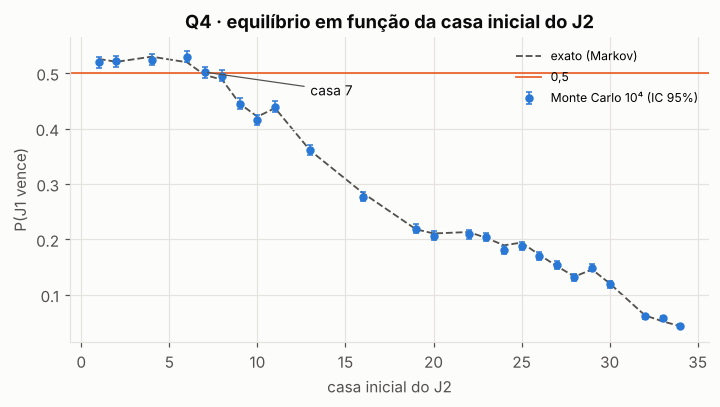

In [14]:
# Gráfico Q4: Monte Carlo (com IC) vs exato
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(q4_tab.index, q4_tab.P_J1_exato, color=TXT2, lw=1.2, ls="--", label="exato (Markov)", zorder=1)
ax.errorbar(q4_tab.index, q4_tab.P_J1, yerr=[q4_tab.P_J1 - q4_tab.ic_inf, q4_tab.ic_sup - q4_tab.P_J1],
            fmt="o", ms=4.5, color=AZUL, ecolor=AZUL, elinewidth=1, capsize=2,
            label="Monte Carlo 10⁴ (IC 95%)", zorder=2)
ax.axhline(.5, color=LARANJA, lw=1.2, label="0,5")
ax.annotate(f"casa {melhor}", (melhor, q4_tab.loc[melhor, "P_J1"]), (melhor + 6, .46),
            color=TXT, fontsize=9, arrowprops=dict(arrowstyle="-", color=TXT2, lw=.8))
ax.set(xlabel="casa inicial do J2", ylabel="P(J1 vence)",
       title="Q4 · equilíbrio em função da casa inicial do J2")
ax.legend(loc="upper right", fontsize=8)
plt.show()

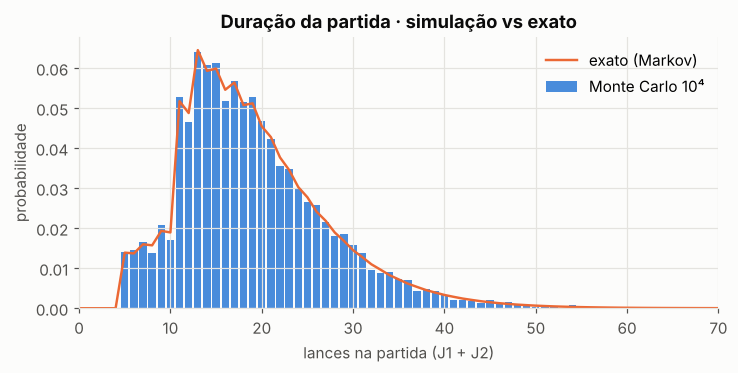

In [15]:
# Distribuição da duração da partida: simulação vs exato
n = np.arange(1, NMAX + 1)
pmf = np.zeros(2 * NMAX + 1)
np.add.at(pmf, 2*n - 1, J["f"] * J["S"][:-1])
np.add.at(pmf, 2*n,     J["f"] * J["S"][1:])
emp = base.lances.value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar(emp.index, emp.values, width=.8, color=AZUL, alpha=.85, label="Monte Carlo 10⁴")
ax.plot(np.arange(len(pmf)), pmf, color=LARANJA, lw=1.6, label="exato (Markov)")
ax.set(xlim=(0, 70), xlabel="lances na partida (J1 + J2)", ylabel="probabilidade",
       title="Duração da partida · simulação vs exato")
ax.legend()
plt.show()

### Tabela final — simulação × exato

In [16]:
linhas = []
for k, mc in RESPOSTAS.items():
    ex = EXATO[k]
    if k.startswith("Q4"):
        linhas.append({"pergunta": k, "Monte Carlo (10⁴)": f"casa {mc[0]}",
                       "IC 95%": f"P(J1) {mc[1]:.4f} [{mc[2]:.4f}, {mc[3]:.4f}]",
                       "exato": f"casa {ex}", "exato ∈ IC?": mc[0] == ex})
    else:
        linhas.append({"pergunta": k, "Monte Carlo (10⁴)": f"{mc[0]:.4f}",
                       "IC 95%": f"[{mc[1]:.4f}, {mc[2]:.4f}]",
                       "exato": f"{ex:.4f}", "exato ∈ IC?": bool(mc[1] <= ex <= mc[2])})
final = pd.DataFrame(linhas).set_index("pergunta")
assert final["exato ∈ IC?"].all(), "simulação diverge do exato!"
final

,Monte Carlo (10⁴),IC 95%,exato,exato ∈ IC?
pergunta,,,,
Q1 P(J1 vence),0.5308,"[0.5210, 0.5406]",0.5255,True
Q2 cobras por partida (total),3.0886,"[3.0380, 3.1392]",3.0937,True
Q3 lances por partida (escada 50%),22.3876,"[22.2120, 22.5632]",22.4933,True
Q4 casa inicial do J2,casa 7,"P(J1) 0.5019 [0.4921, 0.5117]",casa 7,True
"Q5 P(J1 vence), J2 imune",0.3828,"[0.3733, 0.3924]",0.3864,True


## 6. Conclusões

| Pergunta | Resposta |
|---|---|
| **Q1** | O jogador que começa vence em **≈ 52,6%** das partidas. A vantagem existe porque ele chega primeiro em caso de "empate" no número de lances. |
| **Q2** | **≈ 3,1 cobras por partida**, somando os dois jogadores: ≈ 1,6 do J1 e ≈ 1,5 do J2. |
| **Q3** | Com escadas a 50%, a partida dura **≈ 22,5 lances** no total, contra ≈ 19,0 com escadas normais. Um jogador sozinho precisa de ≈ 15,5 lances. |
| **Q4** | O J2 deve começar na **casa 7**, que leva a P(J1) ≈ 0,50. |
| **Q5** | Com o J2 imune à primeira cobra, P(J1 vence) **≈ 0,39**. A imunidade mais que compensa a vantagem de jogar primeiro. |

As cinco respostas do Monte Carlo concordam com a solução exata dentro dos intervalos de 95%, e essa checagem é feita por `assert`. Com isso, o simulador está validado.

**Pontos de atenção:**
- Com 10⁴ jogos, o IC de uma proporção tem largura de ≈ ±0,01.
- Na Q4, as casas 7 e 8 ficam ambas perto de 0,5. Usar números aleatórios comuns e a checagem exata é o que torna a escolha da casa 7 robusta.
- Todas as respostas dependem da leitura do tabuleiro (seção 1). Mudar um dicionário reexecuta tudo.